In [96]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

In [97]:
tf.__version__

'2.22.0-dev20260731'

In [98]:
keras.__version__

'3.16.0.dev2026073104'

In [99]:
fashion_mnist = keras.datasets.fashion_mnist
(x_train,y_train), (x_test, y_test) = fashion_mnist.load_data()

In [100]:
x_train[0,:,:]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

In [101]:
import matplotlib.pyplot as plt

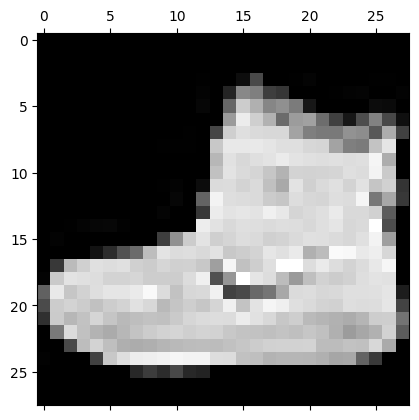

In [102]:
plt.matshow(x_train[0,:,:],cmap=plt.cm.grey)

In [103]:
X_valid, X_train = x_train[:5000] / 255.0, x_train[5000:] / 255.0
y_valid, y_train = y_train[:5000], y_train[5000:]

In [104]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [105]:
fashion_mnist
y_train[1]

np.uint8(0)

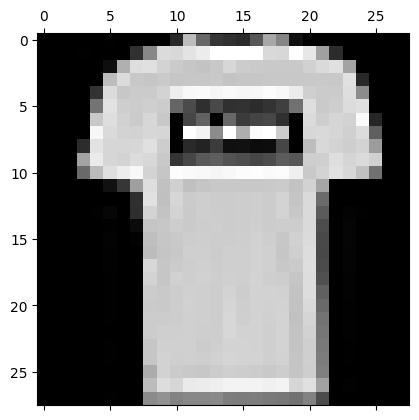

In [106]:
plt.matshow(x_train[1],cmap=plt.cm.grey)

In [107]:
def showimage(dataset):
    plt.matshow(dataset,cmap=plt.cm.grey)
    plt

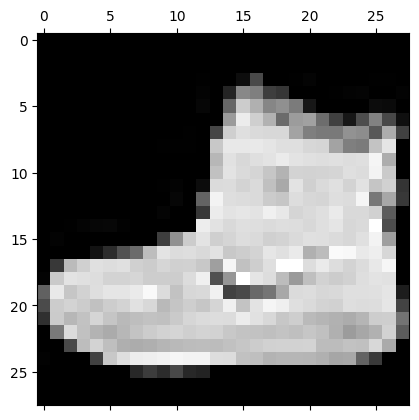

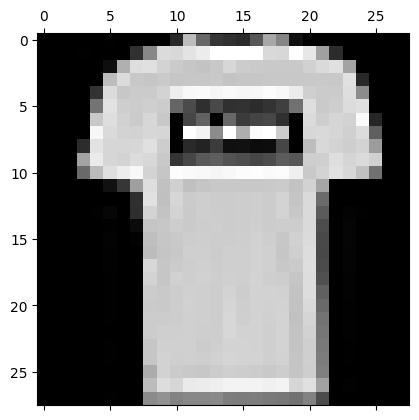

In [108]:
for i in range(2):
    showimage(x_train[i])

In [109]:
import os
rootdir = os.path.join(os.curdir,"Mylogs" )

In [110]:
def get_run_dir():
    import time
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(rootdir , run_id)

In [111]:
run_dir = get_run_dir()
tensorboard_cm = keras.callbacks.TensorBoard(run_dir)

In [112]:
model = keras.Sequential()

In [113]:
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300,activation=keras.activations.relu))
model.add(keras.layers.Dense(100,activation=keras.activations.relu))
model.add(keras.layers.Dense(10,activation=keras.activations.softmax))

In [ ]:
model.compile(loss="sparse_categorical_crossentropy",optimizer=keras.optimizers.SGD(learning_rate=0.01),metrics=[keras.metrics.Accuracy])

In [117]:
print("x_train:",X_train.shape)
print("X_valid:",X_valid.shape)

x_train: (55000, 28, 28)
X_valid: (5000, 28, 28)


In [116]:
model.fit(X_train,y_train,epochs=40,validation_data=(X_valid,y_valid))

Epoch 1/40


ValueError: Dimensions must be equal, but are 32 and 10 for '{{node Equal}} = Equal[T=DT_FLOAT, incompatible_shape_error=true](Cast_2, sequential_5_1/dense_18_1/Softmax)' with input shapes: [32], [32,10].